# Description

Create lists or flags for interesting subsets based on the Kp index

## Method

1. Create labels for different Storm levels (Quiet/G0 to Extreme/G5)


## Resulting Subsets

- based on Intervals
- condition of min length of 2 days (should be always the case)

# Imports and reads

In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
from utils.data_loader import load_parquet

# Load only specific columns that you need for analysis
# This will significantly reduce memory usage
columns_needed = ['time', 'orbital_decay', 'Kp (LASP)']

GFOC_data = load_parquet(columns=columns_needed)
print(GFOC_data.head())

✅ Successfully loaded data with shape: (3157920, 3)
                 time  orbital_decay  Kp (LASP)
0 2023-01-01 00:00:00        16.6730      2.333
1 2023-01-01 00:00:20        16.6730      2.333
2 2023-01-01 00:00:40        16.6735      2.333
3 2023-01-01 00:01:00        16.6740      2.333
4 2023-01-01 00:01:20        16.6740      2.333


In [2]:
df = GFOC_data.copy()
time = df['time'].values

# make 'time' the index
df.set_index('time', inplace=True)
df.index = pd.to_datetime(df.index)
dt_seconds = (df.index[1] - df.index[0]).total_seconds()

In [ ]:
geomagnetic_storm_levels = {
    "G0 (Quiet to Unsettled)": (0.0, 4.99999),
    "G1 (Minor)": (5.0, 5.99999),
    "G2 (Moderate)": (6.0, 6.99999),
    "G3 (Strong)": (7.0, 7.99999),
    "G4 (Severe)": (8.0, 8.999999),
    "G5 (Extreme)": (9.0, 9.99999)
}

def annotate_geomagnetic_storm_events(df):
    for i, level in enumerate(geomagnetic_storm_levels.keys()):
        if 'G0' in level:
            continue

        activity = df['activity_level'].values
        is_level = activity == level
        regions = np.flatnonzero(np.diff(np.concatenate(([0], is_level.view(np.int8), [0]))))
        event_count = len(regions) // 2
        data_samples_per_region = [regions[i + 1] - regions[i] for i in range(0, len(regions), 2)]
        df.loc[df['activity_level'] == level, 'event_number'] = np.repeat(np.arange(1, event_count + 1),
                                                                          data_samples_per_region)
        df.loc[df['activity_level'] == level, 'unique_event_id'] = [int(f'{i}{n}') for n in
                                                                    np.repeat(np.arange(1, event_count + 1),
                                                                              data_samples_per_region)]

    return df

def set_activity_level(df):
    df['activity_level'] = df['Kp (LASP)'].apply(lambda kp: next((level for level, (low, high) in geomagnetic_storm_levels.items() if low <= kp <= high), 'Unknown'))

    # propagate backward the strongest activity levels until the transition to quiet level to the left and right 
    # e.g. G0 G3 G2 G5 G0 -> G0 G5 G5 G5 G0
    activity = df['activity_level'].values
    for level in ["G5 (Extreme)", "G4 (Severe)", "G3 (Strong)", "G2 (Moderate)", "G1 (Minor)"]:
        is_not_quiet = activity != 'G0 (Quiet to Unsettled)'
        is_level = activity == level
        regions = np.flatnonzero(np.diff(np.concatenate(([0], is_not_quiet.view(np.int8), [0]))))
        for start, end in zip(regions[::2], regions[1::2]):
            if is_level[start:end].any():
                activity[start:end] = level
    df['activity_level'] = activity

    N = 4 * 60 * 3 
    activity = df['activity_level'].values
    regions = np.flatnonzero(np.diff(np.concatenate(([0], activity != activity[0],
        [0]))))
    for start, end in zip(regions[::2], regions[1::2]):
        if end - start < N:
            left_level = activity[start - 1] if start > 0 else None
            right_level = activity[end] if end < len(activity) else None
            if left_level == right_level and left_level is not None and left_level != 'G0 (Quiet to Unsettled)':
                activity[start:end] = left_level
    df['activity_level'] = activity

    df = annotate_geomagnetic_storm_events(df)
    df['decay_level'] = df['orbital_decay'].rank(pct=True)
    return df

def annotate_geomag_events_plus_minus_24h(df):
    df['after_event_24h'] = False
    df['before_event_24h'] = False
    df['during_event'] = False
    df['event_window_plus_minus_24h'] = False

    for unique_event in df['unique_event_id'].dropna().unique():
        event_times = df.loc[df['unique_event_id'] == unique_event].index
        
        if len(event_times) == 0:
            continue

        event_start = event_times[0]
        event_end = event_times[-1]
        # print(f"Annotating event: {unique_event} from {event_start} to {event_end}")

        time_24h_before = event_start - pd.Timedelta(hours=24)
        time_24_hours_after = event_end + pd.Timedelta(hours=24)

        df.loc[(df.index >= time_24h_before) & (df.index < event_start), 'before_event_24h'] = True
        df.loc[(df.index >= event_end) & (df.index <= time_24_hours_after), 'after_event_24h'] = True
        df.loc[(df.index >= event_start) & (df.index <= event_end), 'during_event'] = True
        df.loc[(df.index >= time_24h_before) & (df.index <= time_24_hours_after), 'event_window_plus_minus_24h'] = True

    return df

# Annotate Kp events

In [4]:
df = set_activity_level(df)
df = annotate_geomag_events_plus_minus_24h(df)
print(df['event_window_plus_minus_24h'].value_counts())


event_window_plus_minus_24h
False    2569913
True      588007
Name: count, dtype: int64


# Plot

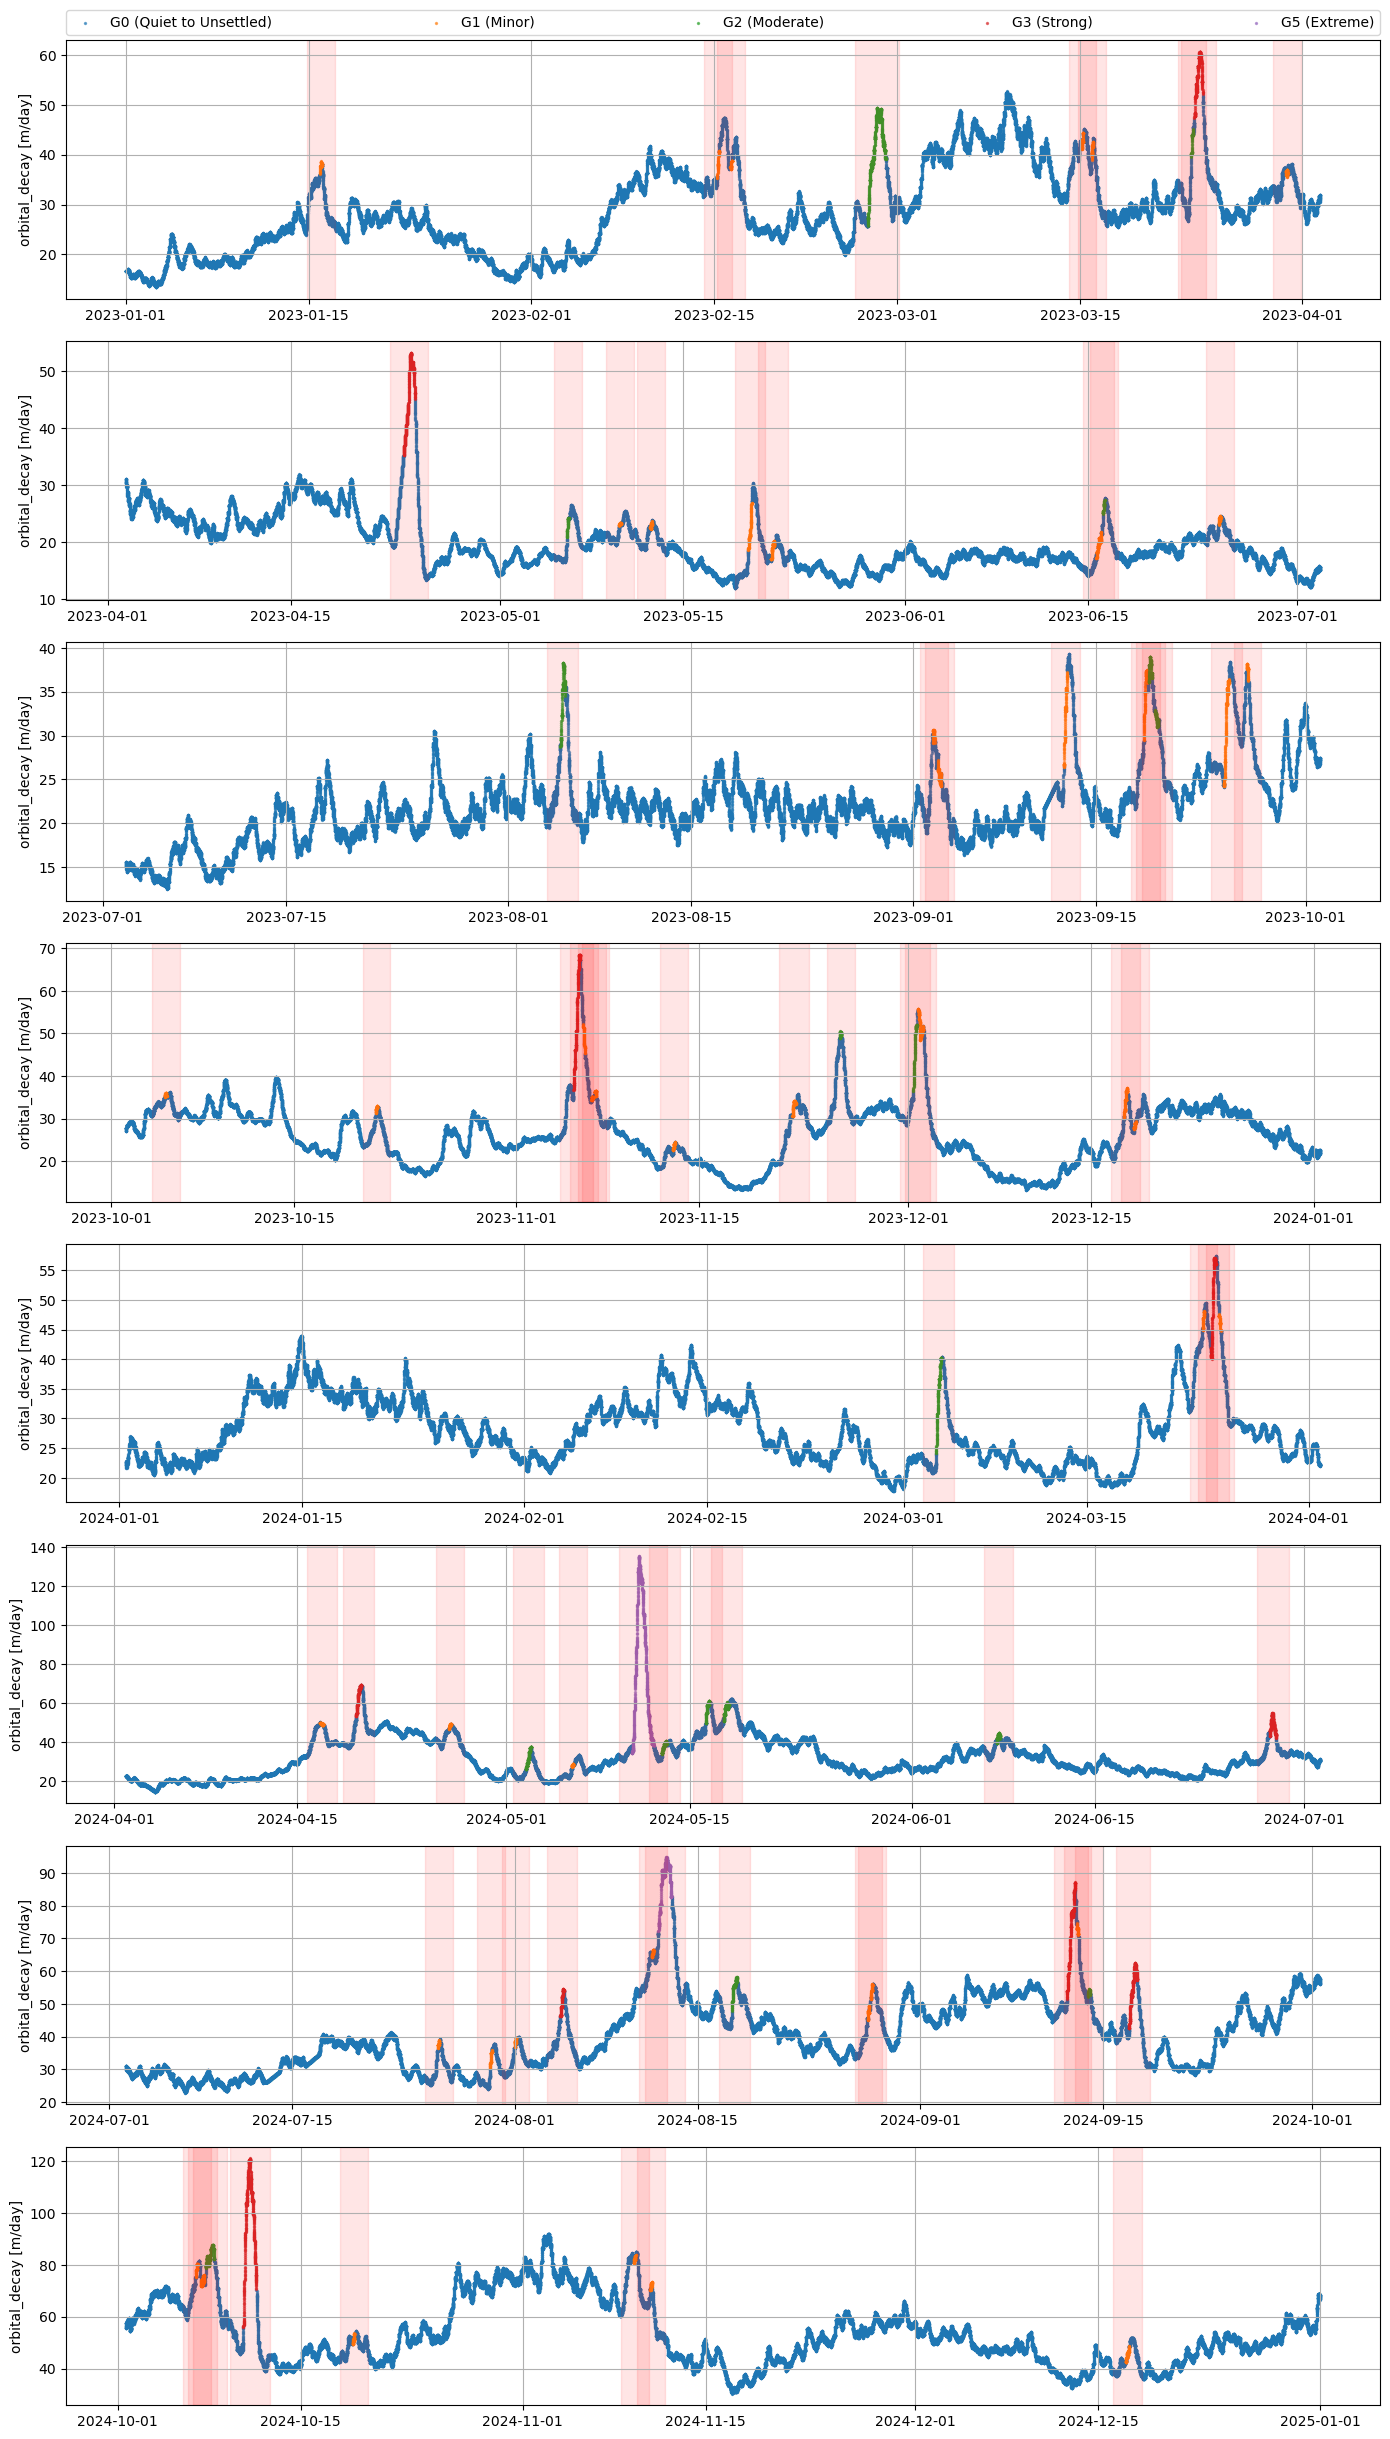

In [5]:
N = 8  # number of subplots

# Downsampled view
ysub = df.iloc[::8]

# split indices into N nearly equal chunks
splits = np.array_split(ysub.index, N)
plt.close('all')
fig, axes = plt.subplots(N, 1, figsize=(14, 3*N), sharey=False)

for ax, idx_chunk in zip(axes, splits):

    # slice the dataframe for this subplot
    chunk = ysub.loc[idx_chunk]

    # split into activity levels
    for level in geomagnetic_storm_levels.keys():
        level_data = chunk[chunk['activity_level'] == level]
        if not level_data.empty:
            ax.scatter(level_data.index, level_data['orbital_decay'], s=2, alpha=0.6, label=level)

    # Kp groups
    event_ids = chunk['unique_event_id'].dropna().unique()
    for event_id in event_ids:
        event_data = chunk[chunk['unique_event_id'] == event_id]
        start_time = event_data.index[0]
        end_time = event_data.index[-1]
        ax.axvspan(start_time - pd.Timedelta(hours=24), end_time + pd.Timedelta(hours=24), color='red', alpha=0.1)

    ax.grid(True)
    ax.set_ylabel("orbital_decay [m/day]")

handles, labels = axes[5].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[0].legend(by_label.values(), by_label.keys(),
    bbox_to_anchor=(0., 1.02, 1., .102), loc='lower left',
    ncols=5, mode="expand", borderaxespad=0.)
plt.tight_layout(rect=[0, 0, 1, 1.02])
plt.show()

# Create and merge intervals

In [6]:
def merge_intervals(df):
    """Merge overlapping time intervals."""
    # Sort intervals by start time
    df = df.sort_values("start").reset_index(drop=True)

    merged = []
    current_start = df.loc[0, "start"]
    current_end = df.loc[0, "end"]

    for i in range(1, len(df)):
        row_start = df.loc[i, "start"]
        row_end = df.loc[i, "end"]

        if row_start <= current_end:  
            # Overlapping or touching intervals → extend the end if needed
            current_end = max(current_end, row_end)
        else:  
            # No overlap → push current and reset
            merged.append((current_start, current_end))
            current_start = row_start
            current_end = row_end

    # Append final interval
    merged.append((current_start, current_end))

    return pd.DataFrame(merged, columns=["start", "end"])

In [7]:
# Kp groups
start_times = []
end_times = []
timedelta = pd.Timedelta(hours=24)

event_ids = df['unique_event_id'].dropna().unique()
for event_id in event_ids:
    event_data = df[df['unique_event_id'] == event_id]
    start_times.append(event_data.index[0] - timedelta)
    end_times.append(event_data.index[-1] + timedelta)

# create dataframe of intervals
intervals_df = pd.DataFrame({"start": start_times, "end": end_times})
merged_intervals_df = merge_intervals(intervals_df)
print("Merged Intervals:")
print(merged_intervals_df)
# save to csv
merged_intervals_df.to_csv('./Analysis/modeling/subsets_Kp.csv', index=False)

Merged Intervals:
                 start                 end
0  2023-01-14 21:00:00 2023-01-16 23:59:00
1  2023-02-14 06:00:00 2023-02-17 08:59:00
2  2023-02-25 18:00:00 2023-03-01 02:59:40
3  2023-03-14 02:59:40 2023-03-16 23:59:20
4  2023-03-22 11:59:20 2023-03-25 08:59:20
5  2023-03-29 18:00:00 2023-03-31 20:59:00
6  2023-04-22 14:59:40 2023-04-25 11:59:20
7  2023-05-05 02:59:40 2023-05-07 05:59:20
8  2023-05-09 03:00:00 2023-05-11 05:59:00
9  2023-05-11 12:00:00 2023-05-13 14:59:00
10 2023-05-18 23:59:40 2023-05-22 23:59:40
11 2023-06-14 15:00:00 2023-06-17 05:59:20
12 2023-06-24 00:00:00 2023-06-26 02:59:00
13 2023-08-04 00:00:00 2023-08-06 08:59:20
14 2023-09-01 12:00:00 2023-09-04 02:59:00
15 2023-09-11 12:00:00 2023-09-13 17:59:00
16 2023-09-17 15:00:00 2023-09-20 17:59:00
17 2023-09-23 18:00:00 2023-09-27 14:59:00
18 2023-10-04 03:00:00 2023-10-06 05:59:00
19 2023-10-20 06:00:00 2023-10-22 08:59:00
20 2023-11-04 09:00:00 2023-11-08 02:59:00
21 2023-11-12 00:00:00 2023-11-14 02